# Email Campaign Analysis
**Shashank Pabitwar · September 2026 · Independent analysis of a historical experiment**

## tl;dr
The men's-merchandise email increased purchase conversion by **0.68 percentage points** versus no email; the women's-merchandise email increased it by **0.31 points**. Both planned comparisons pass the Holm-adjusted 5% threshold. Revenue is variable, so an editable budget scenario and a fresh experiment are more useful than a claim of guaranteed profit.

This notebook reproduces the reasoning, checks key numbers, and keeps plotting code editable. It does not claim that I ran the original experiment or delivered a business revenue increase.

## Context & Methods
The [original MineThatData challenge](https://blog.minethatdata.com/2008/03/minethatdata-e-mail-analytics-and-data.html) describes random assignment to two emails and a no-email control, with two-week outcomes. The analysis population is every assigned customer, including zero-spend customers.

Primary outcome: purchase conversion. Two-sided Fisher exact tests compare each email with control; Holm controls the two-test family. Newcombe difference intervals are shown at 97.5% individually for a Bonferroni family coverage of at least approximately 95%. These are approximate intervals, distinct from the exact Fisher test. Secondary revenue intervals are individual 95% percentile bootstrap intervals (5,000 draws, fixed seed). Segments and adjusted regression are sensitivity/exploratory analyses.

The analysis plan in `docs/analysis-plan.md` was written before this project's calculations but is retrospective, not a preregistration. The dataset has long been publicly studied.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

ROOT=Path.cwd()
if ROOT.name == 'artifacts': ROOT=ROOT.parent
assert (ROOT/'sql/01_prepare.sql').exists(), 'Run from the repository root or artifacts directory.'
sys.path.insert(0,str(ROOT/'scripts'))
from analyze import contrast, bootstrap_means, budget
result=json.loads((ROOT/'data/processed/results.json').read_text())
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,'axes.spines.top':False,'axes.spines.right':False,'figure.dpi':130})
FIG=ROOT/'artifacts/figures'; FIG.mkdir(exist_ok=True,parents=True)
print('Analysis seed:',result['meta']['seed'],'| Bootstrap draws:',result['meta']['bootstrap_draws'])

Analysis seed: 20260917 | Bootstrap draws: 5000


## Data
Download the original extract with `python scripts/fetch_data.py`, then run the pipeline. The public repository distributes aggregate analysis outputs, not a copy of the source records.

There is no customer identifier. The generated row key identifies an extract row only. Exact repeated profiles are retained: dropping them would remove valid-looking customers without evidence that they are accidental duplicates. `Surburban` is standardized to `Suburban` in a derived field. Campaign names describe merchandise, not recipient gender.

In [2]:
raw=pd.read_csv(ROOT/'data/raw/hillstrom.csv')
con=duckdb.connect()
con.register('raw_customers',raw)
con.execute((ROOT/'sql/01_prepare.sql').read_text())
summary=con.sql((ROOT/'sql/02_arm_summary.sql').read_text()).df()
summary=summary.set_index('campaign').loc[['No email',"Men's merchandise","Women's merchandise"]].reset_index()
quality=pd.DataFrame(result['quality'])
assert len(raw)==64000 and quality.passed.all()
assert int(summary.purchasers.sum())==578
assert np.isclose(summary.total_revenue.sum(),67258.13)
print(f'{len(quality)} of {len(quality)} quality checks passed; {raw.duplicated().sum():,} repeated profiles retained.')
display(summary[['campaign','customers','purchasers','conversion_rate','total_revenue','revenue_per_customer']])

27 of 27 quality checks passed; 6,562 repeated profiles retained.


,campaign,customers,purchasers,conversion_rate,total_revenue,revenue_per_customer
0,No email,21306,122.0,0.005726,13908.33,0.652789
1,Men's merchandise,21307,267.0,0.012531,30311.69,1.422617
2,Women's merchandise,21387,189.0,0.008837,23038.11,1.077202


## Results
### Purchase conversion
Rates are purchases divided by assigned customers, not visitors. A visitor-only denominator would condition on a behavior the email could itself change.

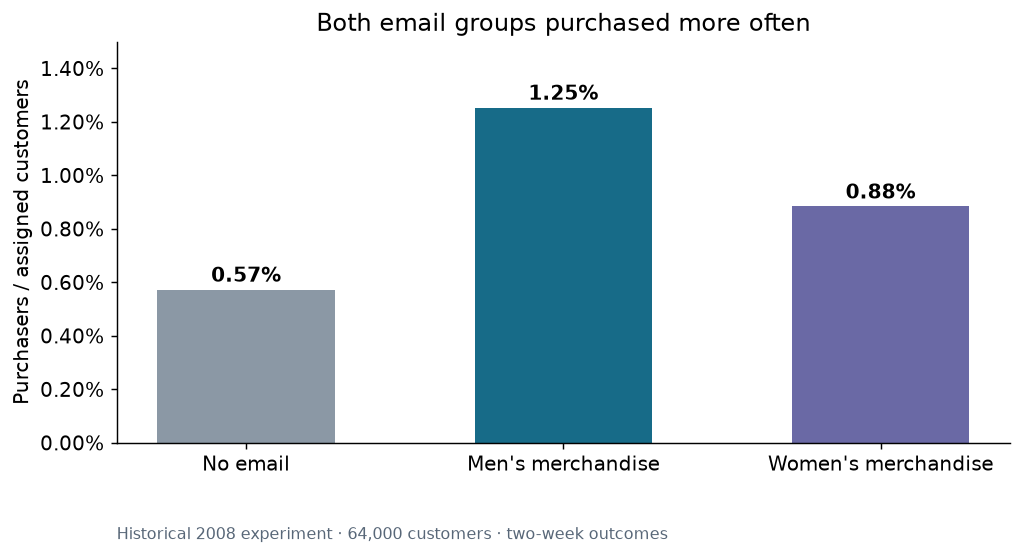

In [3]:
fig,ax=plt.subplots(figsize=(8,4.5))
bars=ax.bar(['No email',"Men's merchandise","Women's merchandise"],summary.conversion_rate,color=['#8B98A5','#176B88','#6A69A5'],width=.56)
ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.set_ylim(0,.015)
ax.set_ylabel('Purchasers / assigned customers'); ax.set_title('Both email groups purchased more often')
for bar,v in zip(bars,summary.conversion_rate): ax.text(bar.get_x()+bar.get_width()/2,v+.0003,f'{v:.2%}',ha='center',fontweight='bold')
ax.text(0,-.24,'Historical 2008 experiment · 64,000 customers · two-week outcomes',transform=ax.transAxes,fontsize=9,color='#586778')
fig.tight_layout();fig.savefig(FIG/'conversion.png',bbox_inches='tight');plt.show()

In [4]:
customers=con.sql('SELECT * FROM customers').df()
control=customers.loc[customers.campaign=='No email','purchased'].to_numpy()
verified=[]
for e in result['effects']:
    treatment=customers.loc[customers.campaign==e['campaign'],'purchased'].to_numpy()
    calculated=contrast(treatment,control,alpha=.025)
    assert np.isclose(calculated['difference'],e['difference'])
    assert np.isclose(calculated['ci_low'],e['family_ci_low'])
    verified.append({'Campaign':e['campaign'],'Uplift (pp)':100*calculated['difference'],
                     'Family lower (pp)':100*calculated['ci_low'],'Family upper (pp)':100*calculated['ci_high'],
                     'Holm p':e['p_holm']})
display(pd.DataFrame(verified).round(6))

,Campaign,Uplift (pp),Family lower (pp),Family upper (pp),Holm p
0,Men's merchandise,0.680501,0.475791,0.891088,0.000000
1,Women's merchandise,0.311106,0.126922,0.498551,0.000165


A **0.68 percentage-point** increase is about 6.8 extra purchasers per 1,000 assigned customers. It is not a 0.68% relative increase. Statistical significance supports a historical effect under the assignment assumptions; it does not tell us today's budget return.

### Revenue, including uncertainty
Spending is mostly zero and highly skewed. The empirical bootstrap resamples all customers, including non-purchasers. Compressing repeated dollar values with multinomial counts is mathematically equivalent to sampling customer indices, while using less memory.

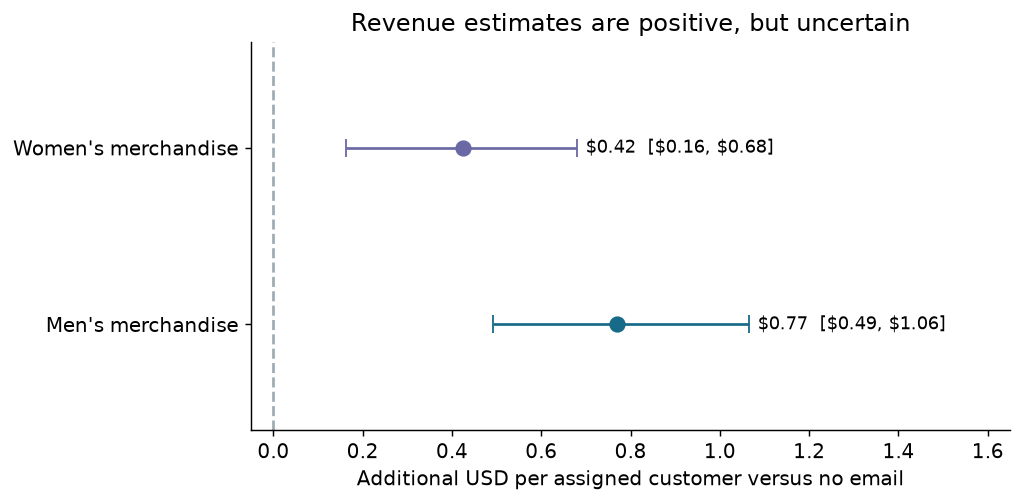

Top 64 customers account for 34.86% of observed revenue.


,campaign,original_difference,capped_difference,pooled_cap
0,Men's merchandise,0.769827,0.659158,243.66049
1,Women's merchandise,0.424412,0.382917,243.66049


In [5]:
rng=np.random.default_rng(result['meta']['seed'])
boot={arm:bootstrap_means(customers.loc[customers.campaign==arm,'revenue'],5000,rng)
      for arm in ['No email',"Men's merchandise","Women's merchandise"]}
fig,ax=plt.subplots(figsize=(8,4))
for i,e in enumerate(result['effects']):
    delta=boot[e['campaign']]-boot['No email']
    low,high=np.quantile(delta,[.025,.975])
    assert np.isclose(low,e['revenue_ci_low']) and np.isclose(high,e['revenue_ci_high'])
    x=e['incremental_revenue']
    ax.errorbar(x,i,xerr=[[x-low],[high-x]],fmt='o',color=['#176B88','#6A69A5'][i],capsize=5,markersize=8)
    ax.text(high+.02,i,f'${x:.2f}  [${low:.2f}, ${high:.2f}]',va='center',fontsize=10)
ax.axvline(0,color='#9EAAB4',linestyle='--');ax.set_yticks([0,1],["Men's merchandise","Women's merchandise"])
ax.set_xlim(-.05,1.65);ax.set_ylim(-.6,1.6);ax.set_xlabel('Additional USD per assigned customer versus no email')
ax.set_title('Revenue estimates are positive, but uncertain')
fig.tight_layout();fig.savefig(FIG/'revenue_uncertainty.png',bbox_inches='tight');plt.show()
print('Top 64 customers account for {:.2%} of observed revenue.'.format(result['diagnostics']['top_revenue_share']))
display(pd.DataFrame(result['revenue_sensitivity']))

The 99.9th-percentile spending cap is a sensitivity analysis, not a replacement outcome. Capping reduces the influence of extreme observations and changes the estimand. The main result keeps the original revenue values.

### Segment exploration and balance
Prior purchase channel and recency existed before assignment. Comparisons within these groups are exploratory and do not validate whom to target. An effect significant in one segment and non-significant in another does not by itself prove that the segment effects differ.

In [6]:
channel=con.sql((ROOT/'sql/05_exploratory_channel_comparison.sql').read_text()).df()
display(channel[['campaign','prior_channel','customers','control_customers','conversion_difference','exploratory_channel_rank']])
print('Equal-allocation chi-square p: {:.4f}'.format(result['diagnostics']['allocation_p']))
print('Maximum absolute pre-treatment standardized difference: {:.4f}'.format(result['diagnostics']['max_abs_smd']))
display(pd.DataFrame(result['regression']))

,campaign,prior_channel,customers,control_customers,conversion_difference,exploratory_channel_rank
0,Men's merchandise,Multichannel,2577,2606,0.010167,1
1,Men's merchandise,Web,9490,9373,0.007200,2
2,Men's merchandise,Phone,9240,9327,0.005462,3
3,Women's merchandise,Multichannel,2579,2606,0.007052,1
4,Women's merchandise,Web,9354,9373,0.003433,2
5,Women's merchandise,Phone,9454,9327,0.001726,3


Equal-allocation chi-square p: 0.9037
Maximum absolute pre-treatment standardized difference: 0.0137


,campaign,adjusted_difference,ci_low,ci_high,p_value,method
0,Men's merchandise,0.006786,0.004983,0.008590,1.629708e-13,Linear probability model; HC3 robust standard ...
1,Women's merchandise,0.003126,0.001514,0.004738,1.436983e-04,Linear probability model; HC3 robust standard ...


The allocation and balance checks are diagnostics; they cannot prove randomization was implemented correctly. Adjusted conversion estimates are close to the unadjusted ones. The linear probability model uses robust HC3 standard errors and pre-treatment covariates only.

### Budget scenarios and the next experiment
The source does not supply campaign costs or margin. A business model must therefore expose those assumptions and avoid calling its output realized profit.

In [7]:
scenario=[]
for e in result['effects']:
    scenario.append({'Campaign':e['campaign'],
        'Modeled contribution':budget(10000,e['incremental_revenue'],.5,.05,500),
        'Historical effect lower':budget(10000,e['revenue_ci_low'],.5,.05,500),
        'Historical effect upper':budget(10000,e['revenue_ci_high'],.5,.05,500)})
display(pd.DataFrame(scenario).round(2))
display(pd.DataFrame(result['power']))
con.close()

,Campaign,Modeled contribution,Historical effect lower,Historical effect upper
0,Men's merchandise,2849.14,1462.14,4323.97
1,Women's merchandise,1122.06,-190.37,2397.32


,baseline_rate,absolute_uplift_pp,power,alpha_per_comparison,customers_per_arm,total_three_arms
0,0.005726,0.1,0.8,0.025,117433,352299
1,0.005726,0.1,0.9,0.025,153338,460014
2,0.005726,0.2,0.8,0.025,31576,94728
3,0.005726,0.2,0.9,0.025,41230,123690
4,0.005726,0.3,0.8,0.025,14989,44967
5,0.005726,0.3,0.9,0.025,19572,58716
6,0.005726,0.5,0.8,0.025,6058,18174
7,0.005726,0.5,0.9,0.025,7910,23730


## Takeaways
1. Use the men's-merchandise creative as the lead candidate in a fresh randomized test. The historical evidence supports increased purchases, not guaranteed current profit.
2. Budget with explicit costs and margin. The default 10,000-contact scenario is approximately **$2,849** contribution for the men's email; the range accounts only for uncertainty in the historical revenue estimate.
3. Investigate segment hypotheses in a new test. Do not deploy a targeting policy selected from noisy in-sample subgroup rankings.
4. For a three-arm study detecting **0.3 percentage points** at 80% power, the normal approximation gives **14,989 customers per arm**, or **44,967 total**, under the historical baseline and multiplicity allowance. Update these assumptions first.

See `docs/decision-memo.md`, `docs/future-experiment.md`, and `docs/methodology.md` for the decision, measurement plan and limitations. No current business deployment or realized revenue improvement is claimed.